In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Facial Analysis/archive_updated.zip'
local_dest = '/content/'

print(f"Copying {zip_path} to {local_dest}...")
!cp "{zip_path}" "{local_dest}"

print("Extracting archive...")
with zipfile.ZipFile(os.path.join(local_dest, 'archive_updated.zip'), 'r') as zip_ref:
    zip_ref.extractall(local_dest)

TRAIN_PATH = '/content/train'
TEST_PATH = '/content/test'

print(f"\nDataset extracted!")
print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")

import os
if os.path.exists(TRAIN_PATH):
    train_classes = os.listdir(TRAIN_PATH)
    print(f"\nTrain classes found: {train_classes}")
    for cls in train_classes:
        cls_path = os.path.join(TRAIN_PATH, cls)
        if os.path.isdir(cls_path):
            print(f"  {cls}: {len(os.listdir(cls_path))} images")

if os.path.exists(TEST_PATH):
    test_classes = os.listdir(TEST_PATH)
    print(f"\nTest classes found: {test_classes}")
    for cls in test_classes:
        cls_path = os.path.join(TEST_PATH, cls)
        if os.path.isdir(cls_path):
            print(f"  {cls}: {len(os.listdir(cls_path))} images")

Copying /content/drive/MyDrive/Facial Analysis/archive_updated.zip to /content/...
Extracting archive...

Dataset extracted!
Train path: /content/train
Test path: /content/test

Train classes found: ['fearful', 'disgusted', 'angry', 'surprised', 'neutral', 'sad', 'happy']
  fearful: 7148 images
  disgusted: 2842 images
  angry: 7159 images
  surprised: 7188 images
  neutral: 10091 images
  sad: 7867 images
  happy: 12259 images

Test classes found: ['fearful', 'disgusted', 'angry', 'surprised', 'neutral', 'sad', 'happy']
  fearful: 1024 images
  disgusted: 111 images
  angry: 958 images
  surprised: 831 images
  neutral: 1233 images
  sad: 1247 images
  happy: 1774 images


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import math
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory Available: 85.17 GB


In [5]:
class Conv2dSame(torch.nn.Conv2d):
    def calc_same_pad(self, i: int, k: int, s: int, d: int) -> int:
        return max((math.ceil(i / s) - 1) * s + (k - 1) * d + 1 - i, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ih, iw = x.size()[-2:]
        pad_h = self.calc_same_pad(i=ih, k=self.kernel_size[0], s=self.stride[0], d=self.dilation[0])
        pad_w = self.calc_same_pad(i=iw, k=self.kernel_size[1], s=self.stride[1], d=self.dilation[1])

        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, [pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2])
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

print("Conv2dSame class defined")

Conv2dSame class defined


In [6]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, i_downsample=None, stride=1, dropout_rate=0.1):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.1)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same', bias=False)
        self.batch_norm2 = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.1)

        self.conv3 = nn.Conv2d(out_channels, out_channels*self.expansion, kernel_size=1, stride=1, padding=0, bias=False)
        self.batch_norm3 = nn.BatchNorm2d(out_channels*self.expansion, eps=0.001, momentum=0.1)

        self.i_downsample = i_downsample
        self.stride = stride
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout2d(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
        identity = x.clone()
        x = self.relu(self.batch_norm1(self.conv1(x)))

        if self.dropout is not None:
            x = self.dropout(x)

        x = self.relu(self.batch_norm2(self.conv2(x)))
        x = self.conv3(x)
        x = self.batch_norm3(x)

        if self.i_downsample is not None:
            identity = self.i_downsample(identity)
        x += identity
        x = self.relu(x)

        return x

print("Bottleneck class defined with spatial dropout")


Bottleneck class defined with spatial dropout


In [7]:
class ResNet(nn.Module):
    def __init__(self, ResBlock, layer_list, num_classes, num_channels=3, dropout_rate=0.05):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv_layer_s2_same = Conv2dSame(num_channels, 64, 7, stride=2, groups=1, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(64, eps=0.001, momentum=0.1)
        self.relu = nn.ReLU()
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2)

        self.layer1 = self._make_layer(ResBlock, layer_list[0], planes=64, stride=1, dropout_rate=dropout_rate)
        self.layer2 = self._make_layer(ResBlock, layer_list[1], planes=128, stride=2, dropout_rate=dropout_rate)
        self.layer3 = self._make_layer(ResBlock, layer_list[2], planes=256, stride=2, dropout_rate=dropout_rate)
        self.layer4 = self._make_layer(ResBlock, layer_list[3], planes=512, stride=2, dropout_rate=dropout_rate)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.dropout1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(512*ResBlock.expansion, 512)
        self.batch_norm_fc = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, num_classes)

    def extract_features(self, x):
        x = self.relu(self.batch_norm1(self.conv_layer_s2_same(x)))
        x = self.max_pool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.dropout1(x)
        x = self.fc1(x)
        return x

    def forward(self, x):
        x = self.extract_features(x)
        x = self.batch_norm_fc(x)
        x = self.relu1(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

    def _make_layer(self, ResBlock, blocks, planes, stride=1, dropout_rate=0.1):
        ii_downsample = None
        layers = []

        if stride != 1 or self.in_channels != planes*ResBlock.expansion:
            ii_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, planes*ResBlock.expansion, kernel_size=1, stride=stride, bias=False, padding=0),
                nn.BatchNorm2d(planes*ResBlock.expansion, eps=0.001, momentum=0.1)
            )

        layers.append(ResBlock(self.in_channels, planes, i_downsample=ii_downsample, stride=stride, dropout_rate=dropout_rate))
        self.in_channels = planes*ResBlock.expansion

        for i in range(blocks-1):
            layers.append(ResBlock(self.in_channels, planes, dropout_rate=dropout_rate))

        return nn.Sequential(*layers)

def ResNet50(num_classes, channels=3, dropout_rate=0.05):
    return ResNet(Bottleneck, [3,4,6,3], num_classes, channels, dropout_rate)

print("ResNet class defined with enhanced regularization")

ResNet class defined with enhanced regularization


In [8]:
class FER2013Dataset(Dataset):
    def __init__(self, root_dir, transform=None, is_training=False):
        self.root_dir = root_dir
        self.transform = transform
        self.is_training = is_training

        self.emotion_map = {
            'angry': 6, 'disgusted': 5, 'fearful': 4,
            'happy': 1, 'neutral': 0, 'sad': 2, 'surprised': 3
        }

        self.samples = []
        for emotion_folder in os.listdir(root_dir):
            emotion_path = os.path.join(root_dir, emotion_folder)
            if os.path.isdir(emotion_path) and emotion_folder in self.emotion_map:
                label = self.emotion_map[emotion_folder]
                for img_name in os.listdir(emotion_path):
                    img_path = os.path.join(emotion_path, img_name)
                    self.samples.append((img_path, label))

        print(f"Loaded {len(self.samples)} images from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((48, 48, 3), dtype=np.uint8)

        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 1:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_LINEAR)

        if self.transform:
            image = self.transform(image)

        image = image.astype(np.float32)
        image = image[..., ::-1].copy()
        image[..., 0] -= 91.4953
        image[..., 1] -= 103.8827
        image[..., 2] -= 131.0912

        image = torch.from_numpy(image).permute(2, 0, 1)

        return image, label

print("FER2013Dataset class defined")

FER2013Dataset class defined


In [9]:
class TrainAugmentation:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image):
        if np.random.rand() < self.p:
            image = cv2.flip(image, 1)

        if np.random.rand() < 0.4:
            angle = np.random.uniform(-15, 15)
            h, w = image.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

        if np.random.rand() < 0.3:
            tx = np.random.randint(-10, 11)
            ty = np.random.randint(-10, 11)
            M = np.float32([[1, 0, tx], [0, 1, ty]])
            image = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]), borderMode=cv2.BORDER_REPLICATE)

        if np.random.rand() < 0.4:
            brightness = np.random.uniform(0.8, 1.2)
            image = np.clip(image * brightness, 0, 255).astype(np.uint8)

        if np.random.rand() < 0.4:
            contrast = np.random.uniform(0.8, 1.2)
            mean = image.mean()
            image = np.clip((image - mean) * contrast + mean, 0, 255).astype(np.uint8)

        if np.random.rand() < 0.2:
            noise = np.random.normal(0, 2, image.shape).astype(np.float32)
            image = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

        if np.random.rand() < 0.15:
            kernel_size = np.random.choice([3, 5])
            image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

        if np.random.rand() < 0.1:
            h, w = image.shape[:2]
            x1, y1 = np.random.randint(0, w//4), np.random.randint(0, h//4)
            x2, y2 = np.random.randint(3*w//4, w), np.random.randint(3*h//4, h)
            image[y1:y2, x1:x2] = np.mean(image)

        return image

train_augmentation = TrainAugmentation(p=0.5)

print("Data augmentation pipeline created with cutout and moderate parameters")

Data augmentation pipeline created with cutout and moderate parameters


In [10]:
BATCH_SIZE = 64
NUM_WORKERS = 4

train_dataset = FER2013Dataset(TRAIN_PATH, transform=train_augmentation, is_training=True)
test_dataset = FER2013Dataset(TEST_PATH, transform=None, is_training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
print(f"  Total train samples: {len(train_dataset)} | Total test samples: {len(test_dataset)}")


Loaded 54554 images from /content/train
Loaded 7178 images from /content/test

DataLoaders created:
  Train batches: 853 | Test batches: 113
  Total train samples: 54554 | Total test samples: 7178


In [11]:
model = ResNet50(num_classes=7, channels=3, dropout_rate=0.05)
model = model.to(device)

train_samples = {'neutral': 10091, 'happy': 12259, 'sad': 7867, 'surprised': 7188,
                 'fearful': 7148, 'disgusted': 2842, 'angry': 7159}
total_samples = sum(train_samples.values())
class_weights = torch.tensor([
    total_samples / (7 * train_samples['neutral']),
    total_samples / (7 * train_samples['happy']),
    total_samples / (7 * train_samples['sad']),
    total_samples / (7 * train_samples['surprised']),
    total_samples / (7 * train_samples['fearful']),
    total_samples / (7 * train_samples['disgusted']),
    total_samples / (7 * train_samples['angry'])
], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel initialized: ResNet50")
print(f"  Total parameters: {total_params:,} | Trainable: {trainable_params:,}")
print(f"  Device: {device}")
print(f"  Loss: CrossEntropyLoss with class weights + label smoothing 0.15")
print(f"\nClass Weights:")
for i, name in enumerate(['Neutral', 'Happiness', 'Sadness', 'Surprise', 'Fear', 'Disgust', 'Anger']):
    print(f"  {name:12s}: {class_weights[i]:.4f}")

LEARNING_RATE = 0.0003
WEIGHT_DECAY = 0.0005
NUM_EPOCHS = 60
WARMUP_EPOCHS = 3

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)

scaler = GradScaler()

print(f"\nOptimizer configured:")
print(f"  Type: AdamW | LR: {LEARNING_RATE} | Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup: {WARMUP_EPOCHS} epochs")
print(f"  Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)")
print(f"  Mixed precision training enabled")
print(f"  Training epochs: {NUM_EPOCHS}")


Model initialized: ResNet50
  Total parameters: 24,561,735 | Trainable: 24,561,735
  Device: cuda
  Loss: CrossEntropyLoss with class weights + label smoothing 0.15

Class Weights:
  Neutral     : 0.7723
  Happiness   : 0.6357
  Sadness     : 0.9906
  Surprise    : 1.0842
  Fear        : 1.0903
  Disgust     : 2.7422
  Anger       : 1.0886

Optimizer configured:
  Type: AdamW | LR: 0.0003 | Weight decay: 0.0005
  Warmup: 3 epochs
  Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Mixed precision training enabled
  Training epochs: 60


In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device, scaler, use_amp=True):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc='Training', leave=False)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc='Validation', leave=False)
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

print("Training and validation functions defined with gradient clipping")

Training and validation functions defined with gradient clipping


In [13]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0
best_model_path = '/content/drive/MyDrive/Facial Analysis/FER_static_ResNet50_optimized.pt'
patience_counter = 0
early_stop_patience = 12

print("=" * 70)
print(f"Starting Training - {NUM_EPOCHS} Epochs")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 70)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"✓ Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1

    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
        print(f"Warmup Phase - Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    else:
        scheduler.step()
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print("\n" + "=" * 70)
print("Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Model saved to: {best_model_path}")
print("=" * 70)

Starting Training - 60 Epochs

Epoch [1/60]
----------------------------------------------------------------------


Train Loss: 2.0505 | Train Acc: 14.25%
Val Loss:   2.0447 | Val Acc:   18.06%
✓ Best model saved! Val Acc: 18.06%
Warmup Phase - Learning Rate: 1.20e-04

Epoch [2/60]
----------------------------------------------------------------------


Train Loss: 2.0000 | Train Acc: 16.40%
Val Loss:   2.0245 | Val Acc:   24.87%
✓ Best model saved! Val Acc: 24.87%
Warmup Phase - Learning Rate: 2.10e-04

Epoch [3/60]
----------------------------------------------------------------------


Train Loss: 1.8131 | Train Acc: 35.33%
Val Loss:   1.8149 | Val Acc:   42.31%
✓ Best model saved! Val Acc: 42.31%
Warmup Phase - Learning Rate: 3.00e-04

Epoch [4/60]
----------------------------------------------------------------------


Train Loss: 1.7035 | Train Acc: 42.95%
Val Loss:   1.7653 | Val Acc:   44.54%
✓ Best model saved! Val Acc: 44.54%
Learning Rate: 2.93e-04

Epoch [5/60]
----------------------------------------------------------------------


...

Train Loss: 1.3084 | Train Acc: 67.29%
Val Loss:   1.4555 | Val Acc:   63.76%
Learning Rate: 2.93e-04

Epoch [38/60]
----------------------------------------------------------------------


Train Loss: 1.3059 | Train Acc: 67.60%
Val Loss:   1.4618 | Val Acc:   64.50%
Learning Rate: 2.89e-04

Epoch [39/60]
----------------------------------------------------------------------


Train Loss: 1.3006 | Train Acc: 67.83%
Val Loss:   1.4409 | Val Acc:   65.59%
Learning Rate: 2.84e-04

Epoch [40/60]
----------------------------------------------------------------------


Train Loss: 1.2905 | Train Acc: 68.32%
Val Loss:   1.4396 | Val Acc:   65.38%
Learning Rate: 2.78e-04

Epoch [41/60]
----------------------------------------------------------------------


Train Loss: 1.2759 | Train Acc: 69.13%
Val Loss:   1.4299 | Val Acc:   65.60%
Learning Rate: 2.71e-04

Early stopping triggered at epoch 41

Training Complete!
Best Validation Accuracy: 67.57%
Model saved to: /content/drive/MyDrive/Facial Analysis/FER_static_ResNet50_optimized.pt


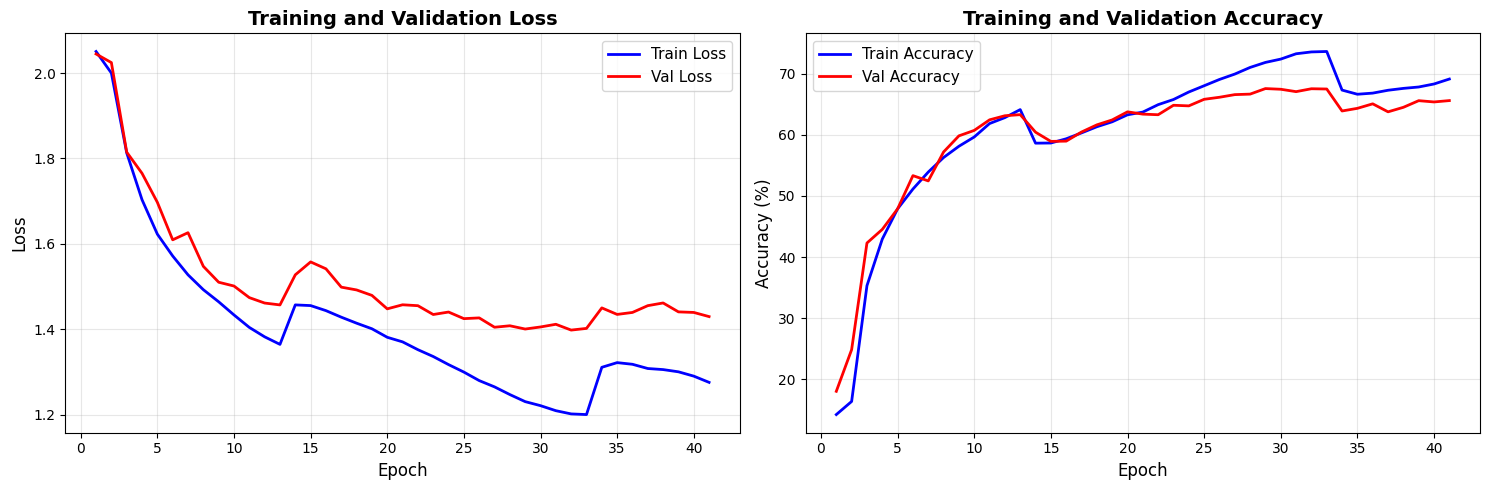

Training curves saved to Google Drive
Final Train Accuracy: 69.13%
Best Validation Accuracy: 67.57%
Evaluating best model on test set...


Evaluating: 100%|██████████| 113/113 [00:03<00:00, 35.23it/s]



CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Neutral     0.6024    0.6537    0.6270      1233
   Happiness     0.8875    0.8540    0.8704      1774
     Sadness     0.5659    0.5581    0.5620      1247
    Surprise     0.8095    0.7822    0.7956       831
        Fear     0.5283    0.5010    0.5143      1024
     Disgust     0.5338    0.6396    0.5820       111
       Anger     0.6014    0.6253    0.6131       958

    accuracy                         0.6757      7178
   macro avg     0.6470    0.6591    0.6521      7178
weighted avg     0.6787    0.6757    0.6768      7178


PER-CLASS ACCURACY
Neutral     :  65.37%
Happiness   :  85.40%
Sadness     :  55.81%
Surprise    :  78.22%
Fear        :  50.10%
Disgust     :  63.96%
Anger       :  62.53%

Overall Test Accuracy: 67.57%
Best Validation Accuracy: 67.57%
MODEL COMPATIBILITY VERIFICATION
✓ Model loaded successfully
✓ Input shape: torch.Size([1, 3, 224, 224])
✓ Output shape: torch.Size([1, 7])
✓ 

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Facial Analysis/training_curves_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to Google Drive")
print(f"Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Best Validation Accuracy: {max(history['val_acc']):.2f}%")


model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

print("Evaluating best model on test set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

emotion_names = ['Neutral', 'Happiness', 'Sadness', 'Surprise', 'Fear', 'Disgust', 'Anger']

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=emotion_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
accuracy_per_class = cm.diagonal() / cm.sum(axis=1) * 100

print("\n" + "=" * 70)
print("PER-CLASS ACCURACY")
print("=" * 70)
for i, emotion in enumerate(emotion_names):
    print(f"{emotion:12s}: {accuracy_per_class[i]:6.2f}%")
print("=" * 70)

overall_acc = 100. * sum(cm.diagonal()) / cm.sum()
print(f"\nOverall Test Accuracy: {overall_acc:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("=" * 70)


test_model = ResNet50(num_classes=7, channels=3, dropout_rate=0.05)
test_model.load_state_dict(torch.load(best_model_path))
test_model.to(device)
test_model.eval()

print("=" * 70)
print("MODEL COMPATIBILITY VERIFICATION")
print("=" * 70)

test_input = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    output = test_model(test_input)
    features = test_model.extract_features(test_input)

print(f"✓ Model loaded successfully")
print(f"✓ Input shape: {test_input.shape}")
print(f"✓ Output shape: {output.shape}")
print(f"✓ Feature shape: {features.shape}")
print(f"✓ Model architecture compatible")

print("\n" + "=" * 70)
print("MODEL SAVED - READY FOR DEPLOYMENT")
print("=" * 70)
print(f"Location: {best_model_path}")
print(f"Final Test Accuracy: {overall_acc:.2f}%")
print("=" * 70)